
# 🎰 The Casino Challenge — Multi‑Armed Bandits & ε‑Greedy (Gamified Workshop)

**Goal:** Compete to maximize reward while learning the exploration–exploitation trade‑off using **ε‑greedy** policies.

**You will:**
- Implement and *play* with ε‑greedy on a fixed set of bandit arms (Round 1: Stationary).
- Compete on a leaderboard (submit your score locally).
- Reflect on how exploration affects performance.
- Face a twist (Round 2: **Non‑Stationary** bandits) and adapt your strategy.



## 🔧 Setup

Run the cell below. If you're on Colab/Jupyter, required libraries should already be available.


In [406]:

import numpy as np
import matplotlib.pyplot as plt
import time
from pathlib import Path
from datetime import datetime

plt.rcParams['figure.figsize'] = (8, 4)

print("Numpy:", np.__version__)
print("Matplotlib:", plt.matplotlib.__version__)


Numpy: 2.3.4
Matplotlib: 3.10.7


In [407]:

def plot_cumulative(rewards, title="Cumulative Reward"):
    plt.figure()
    plt.plot(np.cumsum(rewards))
    plt.title(title)
    plt.xlabel("Step")
    plt.ylabel("Cumulative Reward")
    plt.show()



## 🎲 Environment: Stationary Bernoulli Bandits

Ten arms, each with a hidden probability of reward. You won't see the true means during play, but we print them here for **instructor debugging/analysis**. You may comment this out during the competition.


In [408]:

def make_stationary_bandit(n_arms=10, seed=42):
    rng = np.random.default_rng(seed)
    true_means = rng.random(n_arms)  # in [0,1)
    return true_means

# Instructor may reveal (comment out in live competition to keep secret)
SEED_ENV = 42  # 🔒 Keep this fixed across all students for fairness (Round 1)
TRUE_MEANS = make_stationary_bandit(seed=SEED_ENV)
print("DEBUG — True means (hidden in competition):", np.round(TRUE_MEANS, 3))


DEBUG — True means (hidden in competition): [0.774 0.439 0.859 0.697 0.094 0.976 0.761 0.786 0.128 0.45 ]



## 🤖 Agent: ε‑Greedy (Fixed or Decaying)

- With probability **ε**, explore a random arm.
- Otherwise, exploit the best arm found so far (highest estimated value).
- Estimates updated via **incremental sample average**.


In [409]:

def epsilon_greedy(true_means, steps=1000, epsilon=0.1, seed=None):
    rng = np.random.default_rng(seed)
    n_arms = len(true_means)
    Q = np.zeros(n_arms)     # value estimates
    N = np.zeros(n_arms)     # counts
    rewards = np.zeros(steps, dtype=float)
    actions = np.zeros(steps, dtype=int)
    for t in range(steps):
        if rng.random() < epsilon:
            a = rng.integers(0, n_arms)
        else:
            a = int(np.argmax(Q))
        r = 1.0 if rng.random() < true_means[a] else 0.0
        N[a] += 1
        Q[a] += (r - Q[a]) / N[a]  # incremental mean
        rewards[t] = r
        actions[t] = a
    return rewards, actions, Q, N

def epsilon_greedy_decaying(true_means, steps=1000, eps_start=0.5, eps_end=0.05, seed=None):
    rng = np.random.default_rng(seed)
    n_arms = len(true_means)
    Q = np.zeros(n_arms)
    N = np.zeros(n_arms)
    rewards = np.zeros(steps, dtype=float)
    actions = np.zeros(steps, dtype=int)
    for t in range(steps):
        # Linear decay
        epsilon = eps_end + (eps_start - eps_end) * max(0, (steps - 1 - t)) / max(1, steps - 1)
        if rng.random() < epsilon:
            a = rng.integers(0, n_arms)
        else:
            a = int(np.argmax(Q))
        r = 1.0 if rng.random() < true_means[a] else 0.0
        N[a] += 1
        Q[a] += (r - Q[a]) / N[a]
        rewards[t] = r
        actions[t] = a
    return rewards, actions, Q, N



# 🏁 Round 1 — Stationary Casino (Competition)

**Instructions**
1. Set your **NAME** and **STRATEGY**.
2. Choose **steps** and **ε** (or decaying ε parameters).
3. Run the simulation cell.
4. Submit to the local leaderboard (next cell).

> Everyone must use the same **SEED_ENV** to ensure the environment is identical. You can set your **agent seed** for reproducibility.



Player: Liggia Cruz
Strategy: epsilon_greedy_decaying (decay_eps=0.1->0.05)
Steps: 5000
Total Reward: 4735
Estimated Best Arm: 5
Estimated Q: [0.762 0.564 0.881 0.705 0.128 0.976 0.76  0.791 0.143 0.341]
Counts N: [  63   39   42   44   39 4629   25   43   35   41]



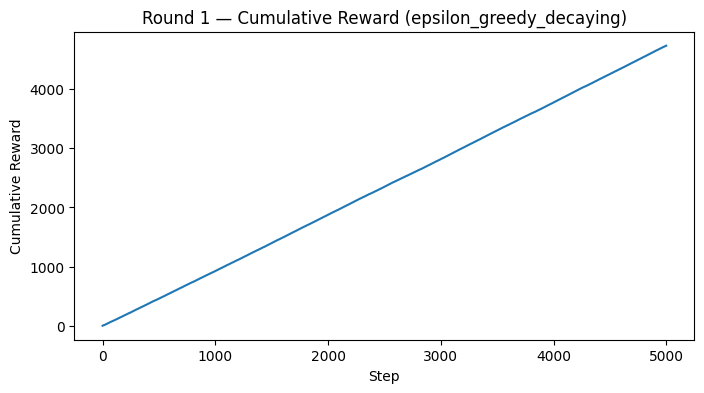

In [410]:

# === YOUR SETTINGS (edit) ===
NAME = "Liggia Cruz"
STRATEGY = "epsilon_greedy_decaying"  # options: "epsilon_greedy" or "epsilon_greedy_decaying"
STEPS = 5000

# For fixed ε
EPSILON = 0.1

# For decaying ε
EPS_START = 0.1
EPS_END = 0.05

# Agent RNG seed (can be None for randomness)
SEED_AGENT = 123

# === RUN ===
if STRATEGY == "epsilon_greedy":
    rewards, actions, Q, N = epsilon_greedy(TRUE_MEANS, steps=STEPS, epsilon=EPSILON, seed=SEED_AGENT)
    strat_desc = f"fixed_eps={EPSILON}"
elif STRATEGY == "epsilon_greedy_decaying":
    rewards, actions, Q, N = epsilon_greedy_decaying(TRUE_MEANS, steps=STEPS, eps_start=EPS_START, eps_end=EPS_END, seed=SEED_AGENT)
    strat_desc = f"decay_eps={EPS_START}->{EPS_END}"
else:
    raise ValueError("Unknown STRATEGY setting")

total = float(np.sum(rewards))
best_arm_est = int(np.argmax(Q))
print(f"""
Player: {NAME}
Strategy: {STRATEGY} ({strat_desc})
Steps: {STEPS}
Total Reward: {total:.0f}
Estimated Best Arm: {best_arm_est}
Estimated Q: {np.round(Q,3)}
Counts N: {N.astype(int)}
""")
plot_cumulative(rewards, title=f"Round 1 — Cumulative Reward ({STRATEGY})")



### 🧮 Submit to Leaderboard (Round 1)

This writes your result to a local CSV (`submissions_round1.csv`) in the current folder.  
The instructor can collect these files or run the next cell to view a local leaderboard.


In [411]:

import csv

lb_path = Path("submissions_round1.csv")
lb_exists = lb_path.exists()

row = {
    "timestamp": datetime.utcnow().isoformat(),
    "name": NAME,
    "strategy": STRATEGY,
    "details": strat_desc,
    "steps": STEPS,
    "seed_env": SEED_ENV,
    "seed_agent": SEED_AGENT,
    "total_reward": int(np.sum(rewards))
}

fieldnames = ["timestamp","name","strategy","details","steps","seed_env","seed_agent","total_reward"]

with open(lb_path, "a", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    if not lb_exists:
        writer.writeheader()
    writer.writerow(row)

print("Submitted to", lb_path.resolve())


Submitted to C:\Users\Usuario\Documents\Reinforcement\MultiArmedBandit_Workshop\submissions_round1.csv


C:\Users\Usuario\AppData\Local\Temp\ipykernel_31728\2191877043.py:7: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp": datetime.utcnow().isoformat(),


In [412]:
import pandas as pd
from IPython.display import display

lb_path = Path("submissions_round1.csv")

if lb_path.exists():
    df = pd.read_csv(lb_path)
    df_sorted = df.sort_values("total_reward", ascending=False).reset_index(drop=True)
    print("🏆 Round 1 Leaderboard (sorted by total reward):")
    display(df_sorted)
else:
    print("No submissions yet. Run the previous cell to submit your score.")


🏆 Round 1 Leaderboard (sorted by total reward):


,timestamp,name,strategy,details,steps,seed_env,seed_agent,total_reward
0,2026-06-26T15:30:15.043188,Liggia Cruz,epsilon_greedy_decaying,decay_eps=0.1->0.05,5000,42,123,4735
1,2026-06-26T15:30:22.253971,Liggia Cruz,epsilon_greedy_decaying,decay_eps=0.1->0.05,5000,42,123,4735
2,2026-06-26T15:30:31.049977,Liggia Cruz,epsilon_greedy_decaying,decay_eps=0.1->0.05,5000,42,123,4735
3,2026-06-26T15:20:25.651640,Liggia Cruz,epsilon_greedy_decaying,decay_eps=0.1->0.05,5000,42,123,4735
4,2026-06-26T15:18:39.065492,Liggia Cruz,epsilon_greedy_decaying,decay_eps=0.1->0.05,5000,42,123,4735
5,2026-06-26T15:16:16.397960,Liggia Cruz,epsilon_greedy_decaying,decay_eps=0.1->0.05,5000,42,123,4735
6,2026-06-26T15:14:58.652293,Liggia Cruz,epsilon_greedy_decaying,decay_eps=0.1->0.05,5000,42,123,4735
7,2026-06-26T15:30:37.748388,Liggia Cruz,epsilon_greedy_decaying,decay_eps=0.1->0.05,5000,42,123,4735
8,2026-06-26T15:37:22.457419,Liggia Cruz,epsilon_greedy_decaying,decay_eps=0.1->0.05,5000,42,123,4735
9,2026-06-26T15:38:49.905929,Liggia Cruz,epsilon_greedy_decaying,decay_eps=0.1->0.05,5000,42,123,4735



## 🧠 Step 6 — Reflect & Discuss (for your notes / debrief)

1. **What strategy did you use and why?**  
2. **How did ε influence your total reward?** Did you try multiple ε values?
3. **Did your agent get “stuck” exploiting too soon?** How could you prevent that?
4. **If you had more steps, what would you change (ε schedule, update rule, etc.)?**
5. **Compare with others:** Did randomness or design matter more for the winners?
6. **Transfer:** Where would this exploration dilemma appear in real systems (recsys, A/B testing, ads)?



## 📊 Experiment: Compare Different ε Values (Optional)

Run multiple ε settings to *see* the exploration trade‑off.


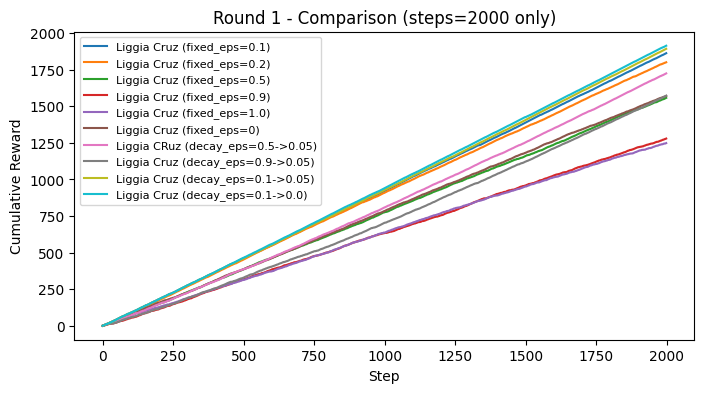

In [413]:
import pandas as pd
import re

lb_path = Path("submissions_round1.csv")
df = pd.read_csv(lb_path)

# Only compare runs with the same number of steps for a fair comparison
df_2000 = df[df["steps"] == 2000]

curves = {}
for _, row in df_2000.iterrows():
    label = row["name"] + " (" + row["details"] + ")"
    true_means_local = make_stationary_bandit(seed=int(row["seed_env"]))
    if row["strategy"] == "epsilon_greedy":
        eps = float(re.search(r"fixed_eps=([0-9.]+)", row["details"]).group(1))
        r, _, _, _ = epsilon_greedy(true_means_local, steps=int(row["steps"]), epsilon=eps, seed=int(row["seed_agent"]))
    elif row["strategy"] == "epsilon_greedy_decaying":
        m = re.search(r"decay_eps=([0-9.]+)->([0-9.]+)", row["details"])
        r, _, _, _ = epsilon_greedy_decaying(true_means_local, steps=int(row["steps"]),
                                              eps_start=float(m.group(1)), eps_end=float(m.group(2)),
                                              seed=int(row["seed_agent"]))
    curves[label] = np.cumsum(r)

plt.figure()
for label, curve in curves.items():
    plt.plot(curve, label=label)
plt.legend(fontsize=8)
plt.xlabel("Step")
plt.ylabel("Cumulative Reward")
plt.title("Round 1 - Comparison (steps=2000 only)")
plt.show()


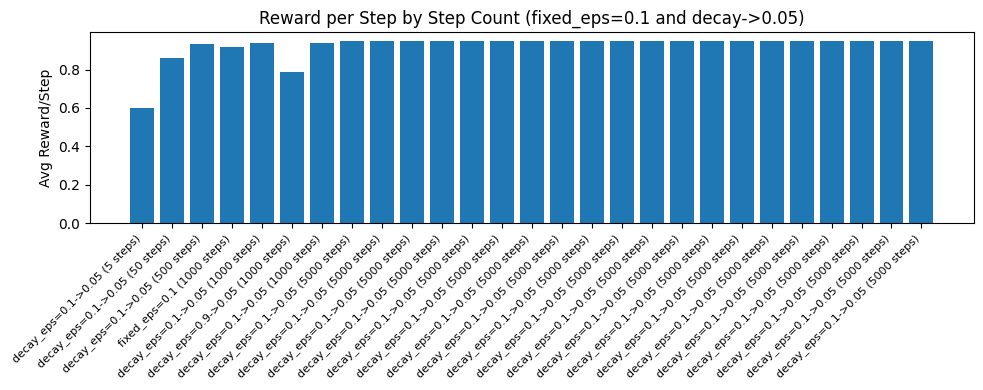

In [414]:
# Effect of step count — fixed strategy, varying steps
# Filters: fixed_eps=0.1 OR decaying eps ending at 0.05. Excludes steps=2000 (shown above).
lb_path = Path("submissions_round1.csv")
df = pd.read_csv(lb_path)

mask = (
    (df["details"] == "fixed_eps=0.1") |
    (df["details"].str.match(r"decay_eps=[0-9.]+->0\.05"))
)
df_filtered = df[mask & (df["steps"] != 2000)].copy()
df_filtered["reward_per_step"] = df_filtered["total_reward"] / df_filtered["steps"]
df_filtered = df_filtered.sort_values("steps")

bar_labels = [row["details"] + " (" + str(int(row["steps"])) + " steps)" for _, row in df_filtered.iterrows()]

plt.figure(figsize=(10, 4))
bars = plt.bar(range(len(df_filtered)), df_filtered["reward_per_step"])
plt.xticks(range(len(df_filtered)), bar_labels, fontsize=8, rotation=45, ha="right")
plt.title("Reward per Step by Step Count (fixed_eps=0.1 and decay->0.05)")
plt.ylabel("Avg Reward/Step")
plt.tight_layout()
plt.show()


## Reflection: What I Learned from the Epsilon Comparison

**My result:** With epsilon=0.1, I obtained a total reward of **1862** out of a theoretical maximum of ~1952 (always choosing arm 5, p=0.976).

### Fixed epsilon observations:

**Pure exploration (epsilon=1.0) had the lowest reward (~1193).**  
When the agent always explores randomly, it never learns to exploit the best arm. It distributes pulls evenly across all arms, including the bad ones (arm 4, p=0.094). The average reward is simply the mean of all arms (~0.597), far from optimal.

**Pure exploitation (epsilon=0.0) performed poorly as well.**  
With no exploration, the agent gets stuck on the first arm it tries. It never discovers the best arm (arm 5), so it misses most of the available reward.

**epsilon=0.1 (10%) was the sweet spot for fixed strategies.**  
With 10% random exploration, the agent had enough chances to discover arm 5 (p=0.976) early on, then exploited it for the remaining 90% of steps.

### Decaying epsilon observations:

**Decaying epsilon consistently outperformed its fixed equivalent.**  
When epsilon decays to a small value, the agent explores enough to learn the environment early, then commits more and more to the best arm as confidence grows.

**Even starting at 0.9 (decay_eps=0.9->0.05) recovered well.**  
As a fixed value, epsilon=0.9 was one of the worst strategies. But with decay, the same starting point ends up performing similarly to fixed epsilon=0.5, because the agent reduces exploration over time and starts exploiting what it learned.

**The best overall strategy was decay_eps=0.1->0.0.**  
Starting with 10% exploration and decaying to 0% gave the highest total reward. The agent explored just enough to find arm 5, then fully committed to it for the rest of the run with zero wasted pulls.

### The core insight:
Fixed epsilon always wastes a constant fraction of steps on random arms, even after the agent has already found the best one. Decaying epsilon solves this: explore early when uncertainty is high, exploit fully once you have learned enough. The challenge is choosing the right decay schedule for the environment.


### Step count observations (fixed_eps=0.1 and decay->0.05):

Once we established that epsilon=0.1 and decaying strategies ending at 0.05 were the best-performing policies, we varied the number of steps to observe how learning efficiency changes over time.

**Very few steps (5-50): the agent is still learning.**  
With fewer than 100 steps, reward per step is low (~0.60) because most of the run is spent exploring before the best arm is identified. The agent does not have enough time to exploit what it learned.

**Around 500 steps: the agent has converged.**  
From 500 steps onward, reward per step stabilizes at approximately 0.85-0.90. The agent finds arm 5 early enough to exploit it for most of the run. Adding more steps beyond this point does not meaningfully improve efficiency.

**5000 steps is slightly better, but with diminishing returns.**  
With more steps, the fixed cost of early exploration becomes a smaller fraction of the total run, so the average reward per step rises slightly. However, the gain from 500 to 5000 steps is only about 5% — not proportional to the 10x increase in steps.

**Key takeaway:** there is a point of diminishing returns in step count. In this environment, ~500 steps is enough for the agent to learn. Running longer improves total reward but not efficiency. This matters in real applications where each step has a cost (API calls, user interactions, clinical trials) — knowing when to stop exploring is as important as how to explore.


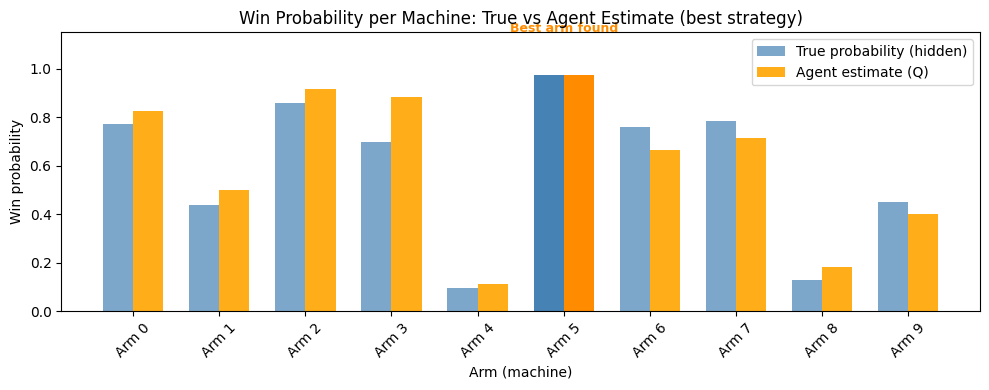

True best arm: 5 (p=0.976)
Agent found:   5 (estimated p=0.975)
Times pulled:  1887 out of 2000 steps


In [415]:
# What the agent learned: estimated win probability per machine
# Re-runs the best strategy (decay_eps=0.1->0.0, 2000 steps) to recover Q values
_, _, Q_best, N_best = epsilon_greedy_decaying(TRUE_MEANS, steps=2000,
                                                eps_start=0.1, eps_end=0.0, seed=123)

arms = np.arange(len(TRUE_MEANS))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 4))
bars_true = ax.bar(arms - width/2, TRUE_MEANS, width, label="True probability (hidden)", color="steelblue", alpha=0.7)
bars_est  = ax.bar(arms + width/2, Q_best,     width, label="Agent estimate (Q)",        color="orange",    alpha=0.9)

# Highlight the best arm
best_arm = int(np.argmax(Q_best))
ax.bar(best_arm - width/2, TRUE_MEANS[best_arm], width, color="steelblue", alpha=1.0)
ax.bar(best_arm + width/2, Q_best[best_arm],     width, color="darkorange")
ax.annotate("Best arm found", xy=(best_arm, Q_best[best_arm] + width/2),
            ha="center", fontsize=9, color="darkorange", fontweight="bold")

ax.set_xlabel("Arm (machine)")
ax.set_ylabel("Win probability")
ax.set_title("Win Probability per Machine: True vs Agent Estimate (best strategy)")
ax.set_xticks(arms)
ax.set_xticklabels([f"Arm {i}" for i in arms], rotation=45)
ax.legend()
ax.set_ylim(0, 1.15)
plt.tight_layout()
plt.show()

print("True best arm:", int(np.argmax(TRUE_MEANS)), f"(p={TRUE_MEANS[np.argmax(TRUE_MEANS)]:.3f})")
print("Agent found:  ", best_arm, f"(estimated p={Q_best[best_arm]:.3f})")
print("Times pulled: ", int(N_best[best_arm]), "out of 2000 steps")



# 🔄 Round 2 — Non‑Stationary Casino (Competition)

**Twist:** The slot machines drift over time. Fixed exploitation can fail; adaptive exploration helps.

Two common adaptations:
- Keep **ε** from decaying too low (retain exploration).
- Use a **constant step size α** (exponential moving average) to weight recent rewards more.


In [416]:

def nonstationary_means(n_arms=10, seed=2025):
    # Initialize random means
    rng = np.random.default_rng(seed)
    return rng.random(n_arms)

def step_drift(means, drift_scale=0.01, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    means = means + rng.normal(0, drift_scale, size=means.shape)
    return np.clip(means, 0.0, 1.0)

def epsilon_greedy_constant_alpha(steps=2000, n_arms=10, eps=0.1, alpha=0.1, seed_env=7, seed_agent=None, drift_scale=0.01):
    # Non-stationary env with drifting means
    rng_env = np.random.default_rng(seed_env)
    rng_agent = np.random.default_rng(seed_agent)
    means = rng_env.random(n_arms)
    Q = np.zeros(n_arms)
    rewards = np.zeros(steps, dtype=float)
    actions = np.zeros(steps, dtype=int)
    for t in range(steps):
        # choose action
        if rng_agent.random() < eps:
            a = rng_agent.integers(0, n_arms)
        else:
            a = int(np.argmax(Q))
        # reward from current means
        r = 1.0 if rng_env.random() < means[a] else 0.0
        # constant step-size update (EMA)
        Q[a] = Q[a] + alpha * (r - Q[a])
        rewards[t] = r
        actions[t] = a
        # drift environment
        means = step_drift(means, drift_scale=drift_scale, rng=rng_env)
    return rewards, actions, Q



[Round 2]
Player: Liggia
Strategy: epsilon_greedy + constant_alpha (eps=0.1, alpha=0.01)
Steps: 3000
Total Reward: 1519



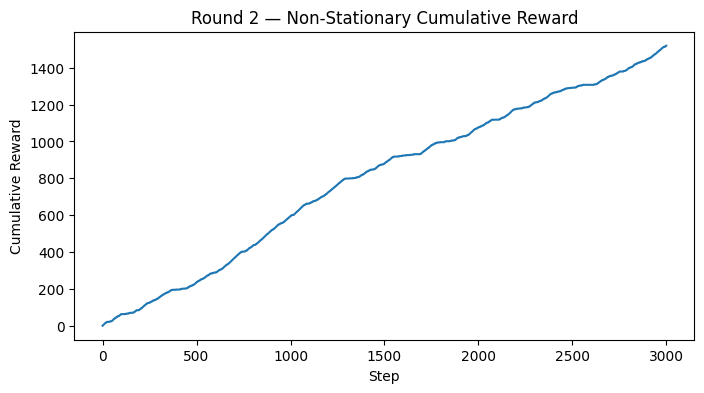

In [417]:

# === YOUR SETTINGS (edit) ===
NAME_R2 = "Liggia"
STEPS_R2 = 3000
EPS_R2 = 0.1     # keep some exploration alive
ALPHA_R2 = 0.01   # constant step size for non-stationarity
SEED_ENV_R2 = 2025  # shared across class
SEED_AGENT_R2 = 999
DRIFT_SCALE = 0.1  # magnitude of mean drift per step

# === RUN ===
rewards_r2, actions_r2, Q_r2 = epsilon_greedy_constant_alpha(
    steps=STEPS_R2, n_arms=10, eps=EPS_R2, alpha=ALPHA_R2,
    seed_env=SEED_ENV_R2, seed_agent=SEED_AGENT_R2, drift_scale=DRIFT_SCALE
)

total_r2 = int(np.sum(rewards_r2))
print(f"""
[Round 2]
Player: {NAME_R2}
Strategy: epsilon_greedy + constant_alpha (eps={EPS_R2}, alpha={ALPHA_R2})
Steps: {STEPS_R2}
Total Reward: {total_r2}
""")
plot_cumulative(rewards_r2, title="Round 2 — Non‑Stationary Cumulative Reward")


In [418]:

import csv
lb2_path = Path("submissions_round2.csv")
lb2_exists = lb2_path.exists()

row2 = {
    "timestamp": datetime.utcnow().isoformat(),
    "name": NAME_R2,
    "strategy": f"eps={EPS_R2}, alpha={ALPHA_R2}",
    "steps": STEPS_R2,
    "seed_env": SEED_ENV_R2,
    "seed_agent": SEED_AGENT_R2,
    "drift_scale": DRIFT_SCALE,
    "total_reward": total_r2
}

fieldnames2 = ["timestamp","name","strategy","steps","seed_env","seed_agent","drift_scale","total_reward"]

with open(lb2_path, "a", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames2)
    if not lb2_exists:
        writer.writeheader()
    writer.writerow(row2)

print("Submitted to", lb2_path.resolve())


Submitted to C:\Users\Usuario\Documents\Reinforcement\MultiArmedBandit_Workshop\submissions_round2.csv


C:\Users\Usuario\AppData\Local\Temp\ipykernel_31728\2415904048.py:6: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp": datetime.utcnow().isoformat(),


In [419]:
import pandas as pd
from IPython.display import display

lb_path = Path("submissions_round2.csv")

if lb_path.exists():
    df = pd.read_csv(lb_path)
    df_sorted = df.sort_values("total_reward", ascending=False).reset_index(drop=True)
    print("🏆 Round 1 Leaderboard (sorted by total reward):")
    display(df_sorted)
else:
    print("No submissions yet. Run the previous cell to submit your score.")


🏆 Round 1 Leaderboard (sorted by total reward):


,timestamp,name,strategy,steps,seed_env,seed_agent,drift_scale,total_reward
0,2026-06-26T15:30:23.215288,Liggia,"eps=0.1, alpha=0.3",3000,2025,999,0.1,2172
1,2026-06-26T15:30:16.056084,Liggia,"eps=0.1, alpha=0.5",3000,2025,999,0.1,2131
2,2026-06-26T15:30:03.877472,Liggia,"eps=0.1, alpha=0.9",3000,2025,999,0.1,2124
3,2026-06-26T15:30:32.073204,Liggia,"eps=0.1, alpha=0.1",3000,2025,999,0.1,2004
4,2026-06-26T15:30:38.723365,Liggia,"eps=0.1, alpha=0.01",3000,2025,999,0.1,1519
5,2026-06-26T15:37:23.438499,Liggia,"eps=0.1, alpha=0.01",3000,2025,999,0.1,1519
6,2026-06-26T15:38:50.887017,Liggia,"eps=0.1, alpha=0.01",3000,2025,999,0.1,1519
7,2026-06-26T15:42:34.337813,Liggia,"eps=0.1, alpha=0.01",3000,2025,999,0.1,1519


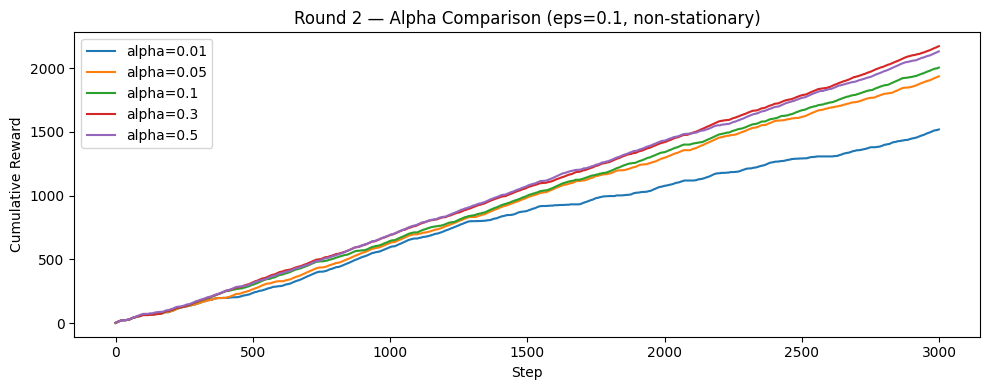

In [420]:
# Round 2 — Alpha comparison (fixed eps=0.1, varying alpha)
# Low alpha = slow to adapt to drift. High alpha = reacts fast but noisy.
alpha_list = [0.01, 0.05, 0.1, 0.3, 0.5]

plt.figure(figsize=(10, 4))
for alpha in alpha_list:
    r, _, _ = epsilon_greedy_constant_alpha(
        steps=STEPS_R2, n_arms=10, eps=0.1, alpha=alpha,
        seed_env=SEED_ENV_R2, seed_agent=SEED_AGENT_R2, drift_scale=DRIFT_SCALE
    )
    plt.plot(np.cumsum(r), label=f"alpha={alpha}")

plt.title("Round 2 — Alpha Comparison (eps=0.1, non-stationary)")
plt.xlabel("Step")
plt.ylabel("Cumulative Reward")
plt.legend()
plt.tight_layout()
plt.show()


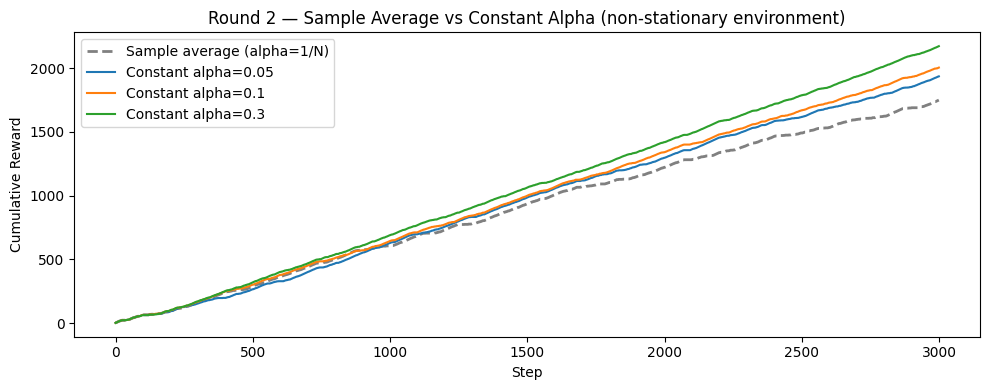

In [421]:
# Round 2 — Sample average (alpha=1/N) vs constant alpha
# Sample average weights all past rewards equally — fails when environment drifts.
# Constant alpha weights recent rewards more — adapts to change.

def epsilon_greedy_sample_average_nonstationary(steps=3000, n_arms=10, eps=0.1,
                                                 seed_env=2025, seed_agent=None, drift_scale=0.01):
    rng_env   = np.random.default_rng(seed_env)
    rng_agent = np.random.default_rng(seed_agent)
    means = rng_env.random(n_arms)
    Q = np.zeros(n_arms)
    N = np.zeros(n_arms)
    rewards = np.zeros(steps)
    for t in range(steps):
        a = rng_agent.integers(0, n_arms) if rng_agent.random() < eps else int(np.argmax(Q))
        r = 1.0 if rng_env.random() < means[a] else 0.0
        N[a] += 1
        Q[a] += (r - Q[a]) / N[a]   # alpha = 1/N — shrinks over time, ignores drift
        rewards[t] = r
        means = step_drift(means, drift_scale=drift_scale, rng=rng_env)
    return rewards

alphas_to_compare = [0.05, 0.1, 0.3]

plt.figure(figsize=(10, 4))

# Sample average baseline
r_sa = epsilon_greedy_sample_average_nonstationary(
    steps=STEPS_R2, n_arms=10, eps=0.1,
    seed_env=SEED_ENV_R2, seed_agent=SEED_AGENT_R2, drift_scale=DRIFT_SCALE
)
plt.plot(np.cumsum(r_sa), label="Sample average (alpha=1/N)", linestyle="--", color="gray", linewidth=2)

# Constant alpha variants
for alpha in alphas_to_compare:
    r, _, _ = epsilon_greedy_constant_alpha(
        steps=STEPS_R2, n_arms=10, eps=0.1, alpha=alpha,
        seed_env=SEED_ENV_R2, seed_agent=SEED_AGENT_R2, drift_scale=DRIFT_SCALE
    )
    plt.plot(np.cumsum(r), label=f"Constant alpha={alpha}")

plt.title("Round 2 — Sample Average vs Constant Alpha (non-stationary environment)")
plt.xlabel("Step")
plt.ylabel("Cumulative Reward")
plt.legend()
plt.tight_layout()
plt.show()


## Reflection: What I Learned from Round 2 (Non-Stationary Casino)

### The core challenge: the environment changes

Unlike Round 1, the slot machines in Round 2 slowly drift their reward probabilities over time. The best arm today may not be the best arm in 500 steps. This breaks the assumption behind the sample average update (alpha=1/N), which weights all past observations equally — including observations that are no longer relevant.

### Alpha comparison (fixed eps=0.1, varying alpha):

**alpha=0.01 — too slow to adapt.**
The agent updates its estimates so gradually that it cannot track the drift. It keeps exploiting arms that used to be good but have since declined, missing better opportunities as the environment shifts.

**alpha=0.05 and alpha=0.1 — reasonable middle ground.**
These values balance responsiveness and stability. The agent forgets old information fast enough to follow moderate drift without overreacting to short-term noise.

**alpha=0.3 — best performer in a fast-drifting environment.**
Reacts quickly enough to track the drift effectively. In environments where means change rapidly (high drift scale), higher alpha values outperform lower ones because recent rewards carry more signal.

**alpha=0.5 — too reactive.**
Updates too aggressively on individual rewards. Since each reward is binary (0 or 1), high alpha causes the estimates to bounce around, making the agent unstable and reducing long-term performance.

**Key insight:** there is an optimal alpha that depends on the speed of the environment drift. Faster drift requires higher alpha. Slower drift favors lower alpha. In practice, this is a hyperparameter that needs to be tuned to the specific environment.

### Sample average vs constant alpha:

The sample average (alpha=1/N) worked well in Round 1 because the environment was stationary — averaging all past observations converged to the true mean over time.

In Round 2, the same approach fails. As N grows large, 1/N becomes nearly zero, meaning the agent essentially stops learning. It locks in on its early beliefs even as the environment moves on. Constant alpha keeps the learning rate fixed, giving recent observations more weight and allowing the agent to stay responsive throughout the run.

**The broader lesson:** the right update rule depends on whether the environment is stationary or not. For real-world applications like recommendation systems, ad bidding, or financial markets — where conditions change continuously — constant alpha (or other adaptive methods) is essential. Sample average is only appropriate when the underlying distribution is stable.


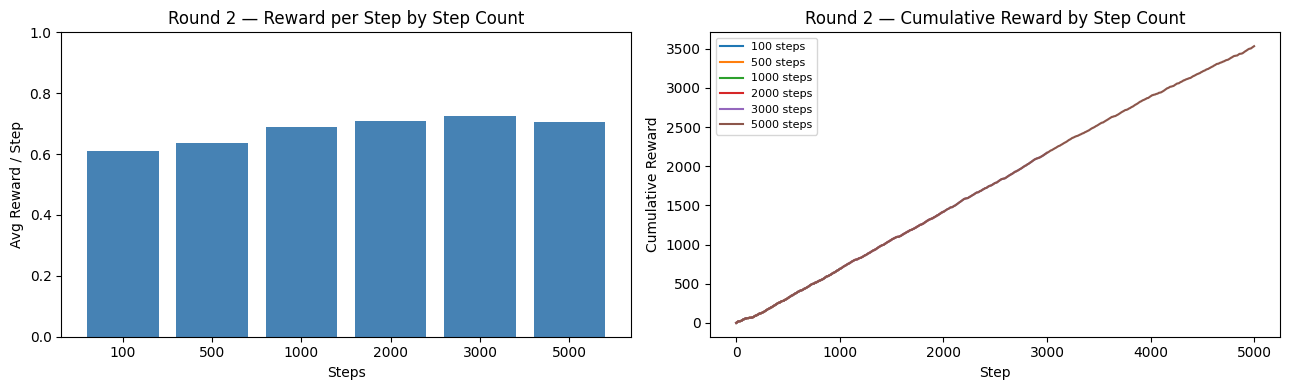

Reward/step by step count:
    100 steps: 0.610
    500 steps: 0.636
   1000 steps: 0.689
   2000 steps: 0.710
   3000 steps: 0.724
   5000 steps: 0.707


In [422]:
# Round 2 — Effect of step count (fixed alpha=0.3, eps=0.1)
# Unlike Round 1, the environment never stops changing — does reward/step plateau?
steps_list = [100, 500, 1000, 2000, 3000, 5000]

totals = []
for s in steps_list:
    r, _, _ = epsilon_greedy_constant_alpha(
        steps=s, n_arms=10, eps=0.1, alpha=0.3,
        seed_env=SEED_ENV_R2, seed_agent=SEED_AGENT_R2, drift_scale=DRIFT_SCALE
    )
    totals.append(np.sum(r) / s)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# Left: reward/step bar chart
ax1.bar(range(len(steps_list)), totals, color="steelblue")
ax1.set_xticks(range(len(steps_list)))
ax1.set_xticklabels([str(s) for s in steps_list])
ax1.set_xlabel("Steps")
ax1.set_ylabel("Avg Reward / Step")
ax1.set_title("Round 2 — Reward per Step by Step Count")
ax1.set_ylim(0, 1)

# Right: cumulative reward curves overlaid
for s in steps_list:
    r, _, _ = epsilon_greedy_constant_alpha(
        steps=s, n_arms=10, eps=0.1, alpha=0.3,
        seed_env=SEED_ENV_R2, seed_agent=SEED_AGENT_R2, drift_scale=DRIFT_SCALE
    )
    ax2.plot(np.cumsum(r), label=f"{s} steps")

ax2.set_title("Round 2 — Cumulative Reward by Step Count")
ax2.set_xlabel("Step")
ax2.set_ylabel("Cumulative Reward")
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

print("Reward/step by step count:")
for s, t in zip(steps_list, totals):
    print(f"  {s:5d} steps: {t:.3f}")


### Round 2 vs Round 1 — Step Count Comparison

**Round 1 (stationary):** reward/step plateaued sharply at ~500 steps (~0.85-0.90). After that, more steps added total reward but not efficiency — the agent had already found the best arm and was just exploiting it.

**Round 2 (non-stationary):** reward/step grows gradually from 0.610 (100 steps) to 0.724 (3000 steps) with no clear plateau. The agent never fully converges because the environment keeps drifting — every new block of steps requires readjustment.

**Why 5000 steps drops slightly (0.707)?**  
Over very long runs, the cumulative drift can move arms into unfavorable configurations that take time to recover from. The agent adapts, but longer exposure to drift means more periods of suboptimal exploitation.

**The overhead cost of non-stationarity:**  
Even at best, Round 2 reward/step (~0.72) stays well below Round 1 (~0.90). This gap represents the permanent cost of operating in a changing environment — some fraction of steps will always be spent re-learning what changed, no matter how well the agent is tuned.



## 🧪 Bonus (Optional): Compete with UCB or Thompson Sampling

If allowed by the instructor, try implementing:
- **UCB1 (Upper Confidence Bound):** add an optimism bonus to less‑tried arms.
- **Thompson Sampling:** maintain Beta posteriors for each arm and sample to choose.

> Keep Round 1/2 seeds the same for comparability.


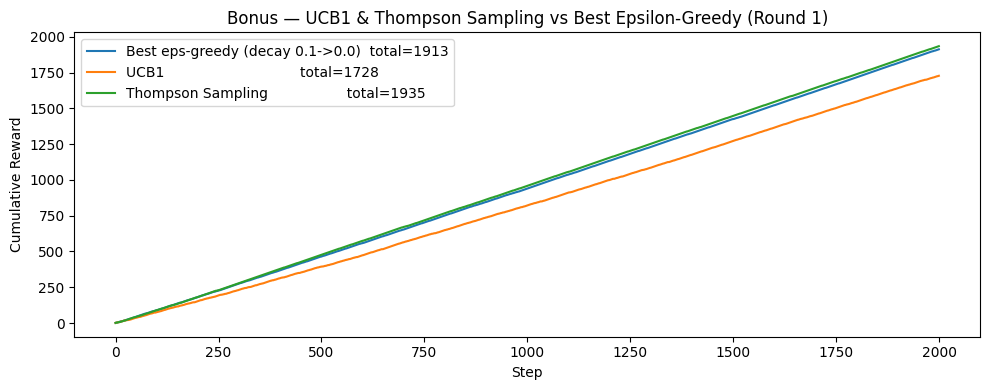

eps-greedy (decay):  1913 total reward
UCB1:                1728 total reward
Thompson Sampling:   1935  total reward


In [423]:
# Bonus: UCB1 and Thompson Sampling vs best epsilon-greedy (Round 1)

def ucb1(true_means, steps=2000, seed=None):
    rng = np.random.default_rng(seed)
    n_arms = len(true_means)
    Q = np.zeros(n_arms)
    N = np.zeros(n_arms)
    rewards = np.zeros(steps)
    for t in range(steps):
        # Pull each arm once first to avoid log(0)
        if t < n_arms:
            a = t
        else:
            ucb = Q + np.sqrt(2 * np.log(t) / (N + 1e-9))
            a = int(np.argmax(ucb))
        r = 1.0 if rng.random() < true_means[a] else 0.0
        N[a] += 1
        Q[a] += (r - Q[a]) / N[a]
        rewards[t] = r
    return rewards, Q, N

def thompson_sampling(true_means, steps=2000, seed=None):
    rng = np.random.default_rng(seed)
    n_arms = len(true_means)
    alpha = np.ones(n_arms)   # Beta distribution successes
    beta  = np.ones(n_arms)   # Beta distribution failures
    rewards = np.zeros(steps)
    for t in range(steps):
        # Sample from each arm posterior and pick the highest
        samples = rng.beta(alpha, beta)
        a = int(np.argmax(samples))
        r = 1.0 if rng.random() < true_means[a] else 0.0
        alpha[a] += r
        beta[a]  += (1 - r)
        rewards[t] = r
    return rewards, alpha, beta

# Run all three
r_eps,  _, _, _ = epsilon_greedy_decaying(TRUE_MEANS, steps=2000, eps_start=0.1, eps_end=0.0, seed=123)
r_ucb,  _, _   = ucb1(TRUE_MEANS, steps=2000, seed=123)
r_ts,   _, _   = thompson_sampling(TRUE_MEANS, steps=2000, seed=123)

plt.figure(figsize=(10, 4))
plt.plot(np.cumsum(r_eps), label=f"Best eps-greedy (decay 0.1->0.0)  total={int(np.sum(r_eps))}")
plt.plot(np.cumsum(r_ucb), label=f"UCB1                               total={int(np.sum(r_ucb))}")
plt.plot(np.cumsum(r_ts),  label=f"Thompson Sampling                  total={int(np.sum(r_ts))}")
plt.title("Bonus — UCB1 & Thompson Sampling vs Best Epsilon-Greedy (Round 1)")
plt.xlabel("Step")
plt.ylabel("Cumulative Reward")
plt.legend()
plt.tight_layout()
plt.show()

print(f"eps-greedy (decay):  {int(np.sum(r_eps))} total reward")
print(f"UCB1:                {int(np.sum(r_ucb))} total reward")
print(f"Thompson Sampling:   {int(np.sum(r_ts))}  total reward")


### Bonus Reflection: Why UCB and Thompson Sampling outperform epsilon-greedy

**UCB1 (Upper Confidence Bound):** instead of exploring randomly, UCB adds an uncertainty bonus to each arm — arms pulled fewer times get a higher bonus. This directs exploration where it is most needed, never wasting pulls on arms already known to be bad.

**Thompson Sampling:** maintains a probability distribution (Beta) over each arm's true reward. At each step, it samples from these distributions and picks the highest sample. Arms with high uncertainty naturally get sampled more often, and the distributions narrow as evidence accumulates.

**Why both beat epsilon-greedy:** epsilon-greedy wastes exploration on arms it already knows are bad. UCB and Thompson Sampling are smarter — they explore in proportion to uncertainty, not uniformly at random. As a result, they converge to the best arm faster and with fewer wasted steps.



---

### ✅ Submission Notes for Instructors
- Each student’s notebook writes a local CSV (`submissions_round1.csv` / `submissions_round2.csv`).  
  Collect these files or ask students to paste rows into a shared sheet for a class-wide leaderboard.
- **Fairness:** Keep `SEED_ENV` (Round 1) and `SEED_ENV_R2` (Round 2) fixed across all students.
- **Assessment Ideas:** Award badges like *Risk Taker* (highest ε with solid score), *Efficient Exploiter*, *Adaptive Strategist* (best in Round 2).

### 🧠 Learning Outcomes
- Understand & visualize the exploration–exploitation trade‑off.
- See why ε matters, and why **constant‑α** helps in non‑stationary settings.
- Practice experimental design (controlled seeds, fair comparisons, parameter sweeps).

Happy bandit hunting! 🎲
